## Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
# OS and File management
import os
import zipfile
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras import Model

In [2]:
# !wget --no-check-certificate https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip -O /content/cats_and_dogs_filtered.zip

## Extract Data and Build Dir Structure

In [4]:
local_path = r'C:\Users\AmitLuhar\training\dataset\day23\cats_and_dogs_filtered.zip'

In [5]:
zip_ref = zipfile.ZipFile(local_path,'r')
zip_ref.extractall(r'C:\Users\AmitLuhar\training\dataset\day23')
zip_ref.close()

In [6]:
base_dir = r'C:\Users\AmitLuhar\training\dataset\day23\cats_and_dogs_filtered'
train_dir = os.path.join(base_dir,'train')
validation_dir = os.path.join(base_dir,'validation')

In [7]:
train_cats_dir = os.path.join(train_dir,'cats')
train_dogs_dir = os.path.join(train_dir,'dogs')
validation_cats_dir = os.path.join(validation_dir,'cats')
validation_dogs_dir = os.path.join(validation_dir,'dogs')

In [8]:
train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir)


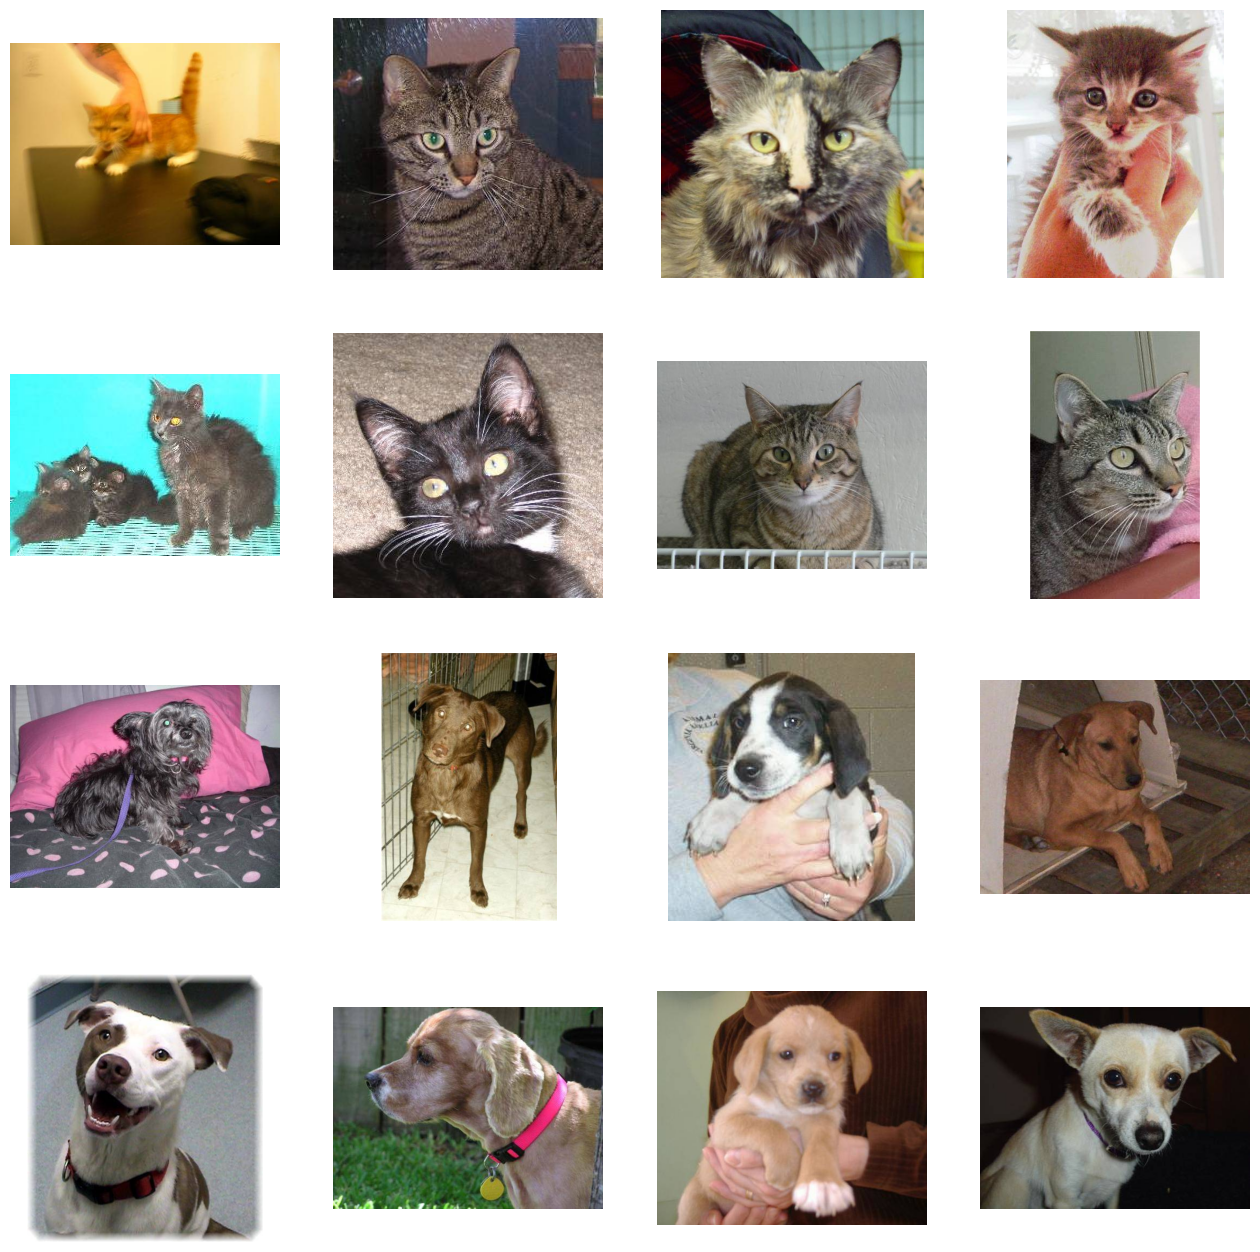

In [9]:
nrows= 4
ncols = 4
pic_index =0
fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)
pic_index=8
next_cat = [os.path.join(train_cats_dir, fname) for fname in train_cats_fnames[pic_index-8:pic_index]]
next_dog = [os.path.join(train_dogs_dir, fname) for fname in train_dogs_fnames[pic_index-8:pic_index]]

for i,  img_path in enumerate(next_cat+next_dog):
  sp = plt.subplot(nrows,ncols, i+1)
  sp.axis("Off")
  img =mpimg.imread(img_path)
  plt.imshow(img)
 

## Build CNN Model using Keras Layers Objects

In [10]:
import tensorflow as tf
import tensorflow.keras as keras

In [11]:
img_input = keras.layers.Input(shape=(150,150,3))
#Layer1
L = keras.layers.Conv2D(16,3,activation='relu')(img_input)
L = keras.layers.MaxPooling2D(2)(L)
#Layer2
L = keras.layers.Conv2D(32,3,activation='relu')(L)
L = keras.layers.MaxPooling2D(2)(L)
#Layer3
L = keras.layers.Conv2D(64,3,activation='relu')(L)
L = keras.layers.MaxPooling2D(2)(L)

F = keras.layers.Flatten()(L)
F = keras.layers.Dense(512,activation='relu')(F)
output = keras.layers.Dense(1,activation='sigmoid')(F)

In [12]:
my_cnn_model = keras.Model(img_input,output)

In [14]:
my_cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

## Train CNN

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop

### Model Compile

In [18]:
my_cnn_model.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.001), metrics=['acc'])

In [19]:
#Rescaling
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

#Fetch Data and Resize
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size = 20,
    class_mode = 'binary')

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size = 20,
    class_mode = 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### Model Fit

In [20]:
history = my_cnn_model.fit(train_generator,steps_per_epoch=100, epochs=15, validation_data=validation_generator,verbose=2)

c:\Users\AmitLuhar\training\env2\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
100/100 - 28s - 280ms/step - acc: 0.5340 - loss: 0.7511 - val_acc: 0.6310 - val_loss: 0.6768
Epoch 2/15
100/100 - 9s - 91ms/step - acc: 0.6300 - loss: 0.6487 - val_acc: 0.5430 - val_loss: 0.6858
Epoch 3/15
100/100 - 9s - 91ms/step - acc: 0.6800 - loss: 0.5914 - val_acc: 0.6660 - val_loss: 0.5998
Epoch 4/15
100/100 - 9s - 92ms/step - acc: 0.7275 - loss: 0.5308 - val_acc: 0.7250 - val_loss: 0.5650
Epoch 5/15
100/100 - 9s - 92ms/step - acc: 0.7715 - loss: 0.4735 - val_acc: 0.6800 - val_loss: 0.6095
Epoch 6/15
100/100 - 9s - 93ms/step - acc: 0.8165 - loss: 0.4209 - val_acc: 0.7250 - val_loss: 0.5565
Epoch 7/15
100/100 - 10s - 101ms/step - acc: 0.8385 - loss: 0.3641 - val_acc: 0.7380 - val_loss: 0.5559
Epoch 8/15
100/100 - 9s - 94ms/step - acc: 0.8815 - loss: 0.2877 - val_acc: 0.6920 - val_loss: 0.8187
Epoch 9/15
100/100 - 10s - 96ms/step - acc: 0.9135 - loss: 0.2220 - val_acc: 0.7080 - val_loss: 0.7157
Epoch 10/15
100/100 - 10s - 100ms/step - acc: 0.9425 - loss: 0.1592 - val_acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


C:\Users\AmitLuhar\AppData\Local\Temp\ipykernel_27912\3076809750.py:39: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
C:\Users\AmitLuhar\AppData\Local\Temp\ipykernel_27912\3076809750.py:42: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')


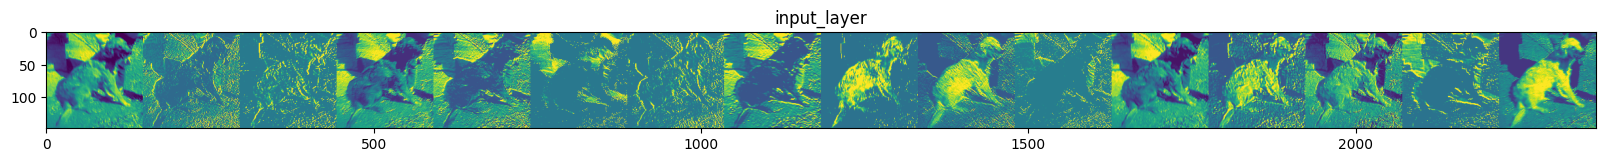

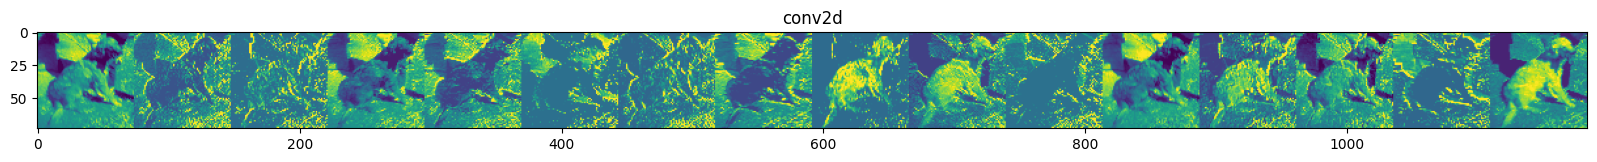

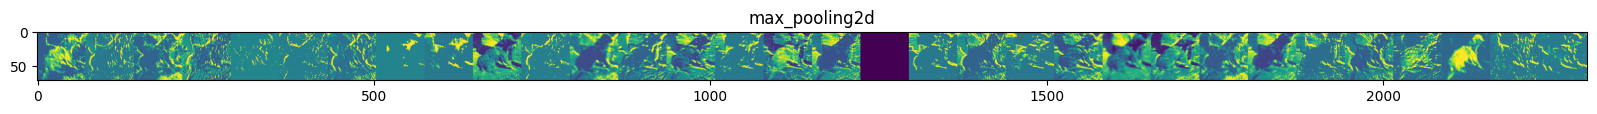

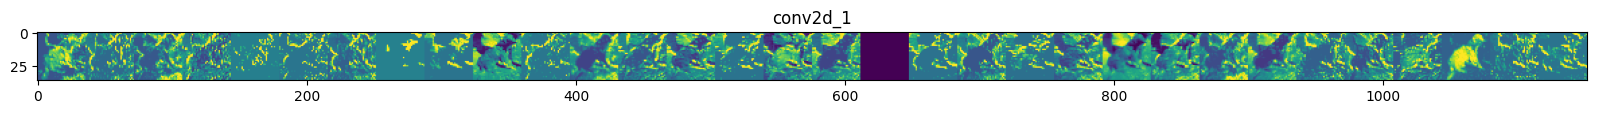

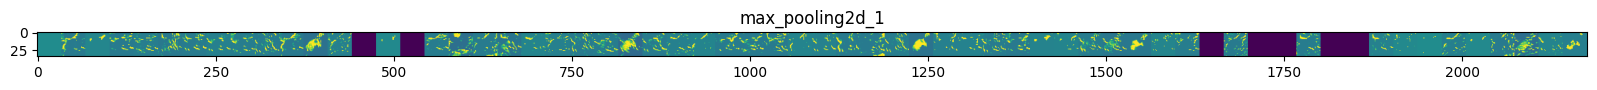

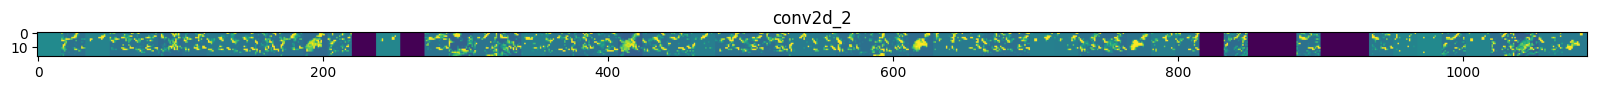

In [24]:
# Let's define a new Model that will take an image as input, and will output
# intermediate representations for all layers in the previous model after
# the first.
successive_outputs = [layer.output for layer in my_cnn_model.layers[1:]]
visualization_model = Model(img_input, successive_outputs)

# Let's prepare a random input image of a cat or dog from the training set.
cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cats_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dogs_fnames]
img_path = random.choice(cat_img_files + dog_img_files)

img = load_img(img_path, target_size=(150, 150))  # this is a PIL image
x = img_to_array(img)  # Numpy array with shape (150, 150, 3)
x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 150, 150, 3)

# Rescale by 1/255
x /= 255

# Let's run our image through our network, thus obtaining all
# intermediate representations for this image.
successive_feature_maps = visualization_model.predict(x)

# These are the names of the layers, so can have them as part of our plot
layer_names = [layer.name for layer in my_cnn_model.layers]

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  if len(feature_map.shape) == 4:
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    n_features = feature_map.shape[-1]  # number of features in feature map
    # The feature map has shape (1, size, size, n_features)
    size = feature_map.shape[1]
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      # Postprocess the feature to make it visually palatable
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # We'll tile each filter into this big horizontal grid
      display_grid[:, i * size : (i + 1) * size] = x
    # Display the grid
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')